# The Prep Problem — How Scheduling Mis-Allocation Cascades Through the OR Day

**Rigshospitalet, 2024–2025**

---

This notebook tells a single, connected story:

> *The scheduling system allocates no prep time to many surgical procedures, causing the first case of the day to start late, which cascades to every case that follows — and the fix is a lookup table.*

### Structure
1. **The problem is prep, not surgery** — where is time actually being lost?
2. **Zero allocation is the worst offender** — some procedures get no planned prep at all
3. **Prep gaps cause late starts** — closing the causal chain
4. **Three types of OR days** — cascading, one-time shock, and recovery
5. **The patient impact** — how many minutes does a patient wait unnecessarily?
6. **We can do better** — complexity predicts prep time

---
> **Data note:** Analysis uses surgical cases with reliable OR prep timestamps (`ts_or_prep_start ≠ ts_or_prep_done`). This is 32% of all cases, skewing towards high-volume surgical specialties. Prep window: `ts_or_prep_start → ts_patient_in_or`.

In [35]:
from pathlib import Path

FIG_DIR = Path('presentation')



---
## 0. Setup

In [36]:
import sys, warnings
warnings.filterwarnings('ignore')

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

sys.path.insert(0, 'src')
from data.loader import load_completed

sns.set_theme(style='whitegrid')
pl.Config.set_tbl_rows(20)
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

BLUE   = '#0077B6'
RED    = '#E63946'
GREEN  = '#2A9D8F'
ORANGE = '#F4A261'
GREY   = '#8D99AE'
PURPLE = '#7B2D8B'

MIN_N = 50

In [37]:
df_raw = load_completed()
df = df_raw.unique(subset=['case_id'], keep='first')

def dur(start, end, name):
    d = (pl.col(end) - pl.col(start)).dt.total_minutes()
    return pl.when(d >= 0).then(d).otherwise(None).alias(name)

def signed_dur(start, end, name):
    return (pl.col(end) - pl.col(start)).dt.total_minutes().alias(name)

staff_cols    = [c for c in df.columns if c.startswith('staff_')]
resource_cols = [c for c in df.columns if c.startswith('resource_')]

df = df.with_columns([
    dur('ts_or_prep_planned_start', 'ts_patient_in_or_planned', 'planned_prep_min'),
    dur('ts_patient_in_or_planned', 'ts_patient_leaves_or_planned', 'planned_inor_min'),
    dur('ts_or_prep_start', 'ts_patient_in_or', 'actual_prep_min'),
    dur('ts_patient_in_or', 'ts_patient_leaves_or', 'actual_inor_min'),
    signed_dur('ts_patient_in_or_planned', 'ts_patient_in_or', 'start_delay_min'),
    signed_dur('ts_patient_leaves_or_planned', 'ts_patient_leaves_or', 'finish_delay_min'),
    pl.sum_horizontal([pl.col(c).cast(pl.Int8, strict=False) for c in staff_cols]).alias('staff_count'),
    pl.sum_horizontal([pl.col(c).cast(pl.Int8, strict=False) for c in resource_cols]).alias('resource_count'),
    pl.col('ts_anesthesia_start').is_not_null().alias('has_anesthesia'),
    pl.col('procedure_text_id').cast(pl.Utf8).str.replace(r'\s*\[.*\]', '').str.strip_chars().alias('procedure_name'),
])

df = df.with_columns([
    (pl.col('actual_prep_min') - pl.col('planned_prep_min')).alias('prep_gap'),
    (pl.col('actual_inor_min') - pl.col('planned_inor_min')).alias('inor_gap'),
])

# Clean surgical subset
SURGICAL = [
    s for s in df['specialty'].unique().to_list()
    if s not in ['Onkologi', 'Pædiatri', 'Neurologi', 'Kardiologi', 'Hæmatologi',
                 'Lungesygdomme', 'Medicinsk gastroenterologi', 'Nefrologi', 'Anæstesiologi']
]

valid = df.filter(
    pl.col('prep_gap').is_not_null() &
    pl.col('inor_gap').is_not_null() &
    (pl.col('prep_gap').abs() < 300) &
    (pl.col('inor_gap').abs() < 300) &
    (pl.col('ts_or_prep_start') != pl.col('ts_or_prep_done')) &
    pl.col('specialty').is_in(SURGICAL)
)

print(f'Analysis set: {valid.shape[0]:,} surgical cases')
print(f'Specialties:  {valid["specialty"].n_unique()}')
print(f'Date range:   {valid["date"].min()} → {valid["date"].max()}')

Analysis set: 38,190 surgical cases
Specialties:  23
Date range:   2024-01-01 → 2025-12-31


---
## 1. The problem is prep, not surgery

The intuitive assumption is that surgery duration is where scheduling goes wrong — unexpected complications, varying surgeon pace, complex cases. But the data tells a different story.

**For 89% of surgical procedures, the gap between planned and actual time is larger in the prep phase than in surgery itself.** The scheduling system is systematically more wrong about a logistical process than about a clinical one.

In [38]:
# Prep gap vs surgery gap
phase_comparison = (
    valid
    .group_by('procedure_name')
    .agg([
        pl.len().alias('n'),
        pl.col('planned_prep_min').mean().round(1).alias('planned_prep'),
        pl.col('actual_prep_min').mean().round(1).alias('actual_prep'),
        pl.col('prep_gap').mean().round(1).alias('prep_gap'),
        pl.col('planned_inor_min').mean().round(1).alias('planned_surgery'),
        pl.col('actual_inor_min').mean().round(1).alias('actual_surgery'),
        pl.col('inor_gap').mean().round(1).alias('surgery_gap'),
    ])
    .filter(pl.col('n') >= MIN_N)
    .with_columns(
        (pl.col('prep_gap').abs() > pl.col('surgery_gap').abs()).alias('prep_worse')
    )
)

pct_prep_worse = phase_comparison['prep_worse'].mean() * 100
mean_prep_gap  = valid['prep_gap'].mean()
mean_inor_gap  = valid['inor_gap'].mean()

print(f'Procedures where prep gap > surgery gap: {pct_prep_worse:.1f}%')
print(f'Mean prep gap:    {mean_prep_gap:+.1f} min')
print(f'Mean surgery gap: {mean_inor_gap:+.1f} min')

Procedures where prep gap > surgery gap: 88.2%
Mean prep gap:    +22.8 min
Mean surgery gap: +6.4 min


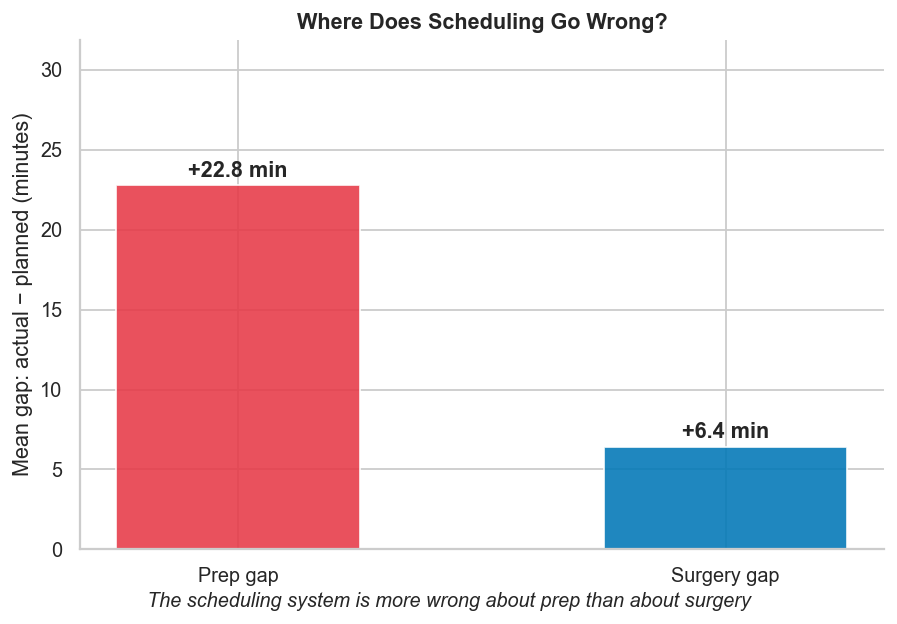

In [39]:
fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(['Prep gap', 'Surgery gap'], [mean_prep_gap, mean_inor_gap],
               color=[RED, BLUE], alpha=0.88, width=0.5, edgecolor='white')
for bar, val in zip(bars, [mean_prep_gap, mean_inor_gap]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:+.1f} min', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Mean gap: actual − planned (minutes)')
ax.set_title('Where Does Scheduling Go Wrong?', fontweight='bold')
ax.set_ylim(0, mean_prep_gap * 1.4)
plt.suptitle('The scheduling system is more wrong about prep than about surgery',
             fontsize=11, style='italic', y=0.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'B.png', dpi=150, bbox_inches='tight')
plt.show()


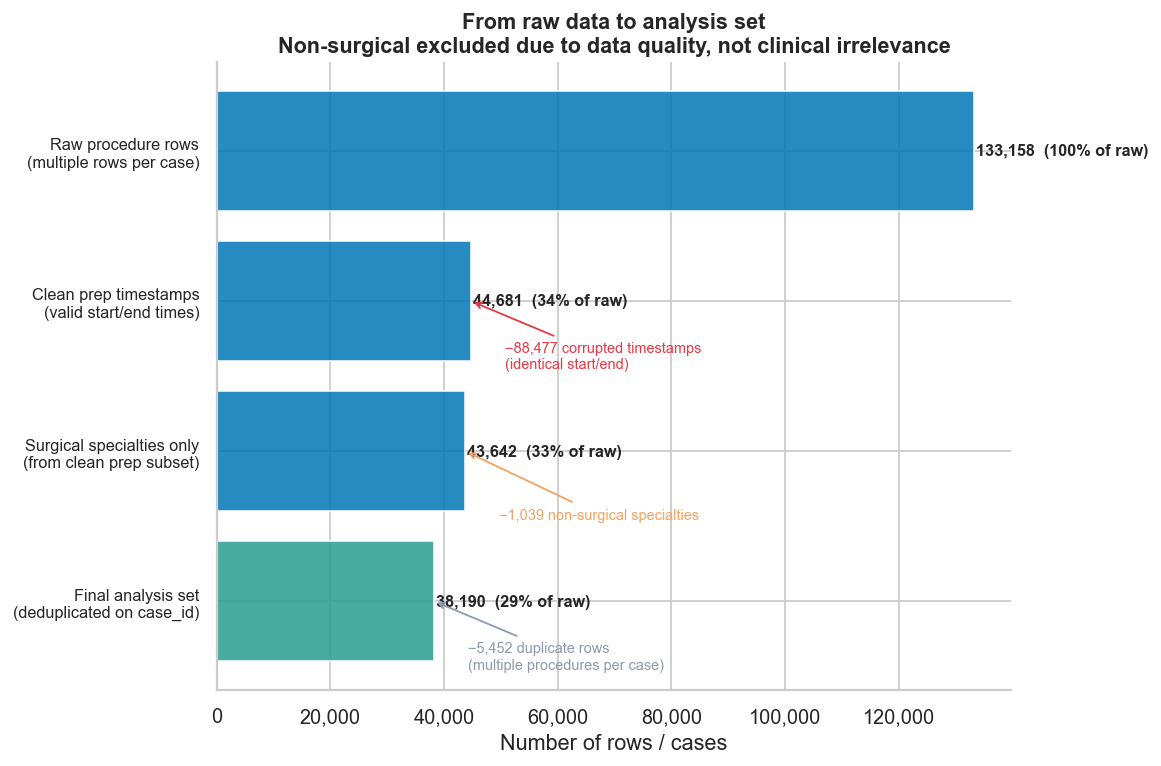

In [40]:
fig, ax = plt.subplots(figsize=(9, 6))

total_raw      = df_raw.shape[0]
clean_prep     = df_raw.filter(pl.col('ts_or_prep_start') != pl.col('ts_or_prep_done')).shape[0]
surgical_clean = df_raw.filter(
    (pl.col('ts_or_prep_start') != pl.col('ts_or_prep_done')) &
    pl.col('specialty').is_in(SURGICAL)
).shape[0]
analysis_set   = valid.shape[0]  # after dedup on case_id

steps = [
    ('Raw procedure rows\n(multiple rows per case)',         total_raw,      BLUE),
    ('Clean prep timestamps\n(valid start/end times)',       clean_prep,     BLUE),
    ('Surgical specialties only\n(from clean prep subset)',  surgical_clean, BLUE),
    ('Final analysis set\n(deduplicated on case_id)',        analysis_set,   GREEN),
]

labels   = [s[0] for s in steps]
values   = [s[1] for s in steps]
colors_f = [s[2] for s in steps]

bars = ax.barh(range(len(steps)), values,
               color=colors_f, alpha=0.85, edgecolor='white')
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()

for bar, val in zip(bars, values):
    pct = val / total_raw * 100
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.0f}% of raw)',
            va='center', fontsize=9, fontweight='bold')

ax.annotate(
    f'−{total_raw - clean_prep:,} corrupted timestamps\n(identical start/end)',
    xy=(clean_prep, 1),
    xytext=(clean_prep + 6000, 1.45),
    fontsize=8, color=RED,
    arrowprops=dict(arrowstyle='->', color=RED, lw=1)
)
ax.annotate(
    f'−{clean_prep - surgical_clean:,} non-surgical specialties',
    xy=(surgical_clean, 2),
    xytext=(surgical_clean + 6000, 2.45),
    fontsize=8, color=ORANGE,
    arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1)
)
ax.annotate(
    f'−{surgical_clean - analysis_set:,} duplicate rows\n(multiple procedures per case)',
    xy=(analysis_set, 3),
    xytext=(analysis_set + 6000, 3.45),
    fontsize=8, color=GREY,
    arrowprops=dict(arrowstyle='->', color=GREY, lw=1)
)

ax.set_xlabel('Number of rows / cases')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_title(
    'From raw data to analysis set\n'
    'Non-surgical excluded due to data quality, not clinical irrelevance',
    fontweight='bold'
)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / '00_data_funnel.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Zero allocation is the worst offender

Many procedures are scheduled with **zero planned prep time** — the scheduler sets `ts_or_prep_planned_start == ts_patient_in_or_planned`, effectively assuming no preparation is needed.

These cases consistently take 30–55 minutes of actual prep. This isn't noise or measurement error — it is a structural blind spot in the scheduling system.

In [41]:
# Split zero vs non-zero allocation
zero_alloc    = phase_comparison.filter(pl.col('planned_prep') == 0)
nonzero_alloc = phase_comparison.filter(pl.col('planned_prep') > 0)

print(f'Procedures with ZERO planned prep: {zero_alloc.shape[0]}')
print(f'  Mean allocated prep: {zero_alloc["planned_prep"].mean():.1f} min')
print(f'  Mean actual prep:    {zero_alloc["actual_prep"].mean():.1f} min')
print(f'  Mean prep gap:       {zero_alloc["prep_gap"].mean():+.1f} min')
print(f'  Mean surgery gap:    {zero_alloc["surgery_gap"].mean():+.1f} min')
print()
print(f'Procedures with planned prep > 0:  {nonzero_alloc.shape[0]}')
print(f'  Mean allocated prep: {nonzero_alloc["planned_prep"].mean():.1f} min')
print(f'  Mean actual prep:    {nonzero_alloc["actual_prep"].mean():.1f} min')
print(f'  Mean prep gap:       {nonzero_alloc["prep_gap"].mean():+.1f} min')
print(f'  Mean surgery gap:    {nonzero_alloc["surgery_gap"].mean():+.1f} min')
print()
print('Top 10 zero-allocation procedures by prep gap:')
zero_alloc.sort('prep_gap', descending=True).select([
    'procedure_name', 'n', 'planned_prep', 'actual_prep', 'prep_gap', 'surgery_gap'
]).head(10)

Procedures with ZERO planned prep: 111
  Mean allocated prep: 0.0 min
  Mean actual prep:    24.3 min
  Mean prep gap:       +24.3 min
  Mean surgery gap:    +4.3 min

Procedures with planned prep > 0:  59
  Mean allocated prep: 12.3 min
  Mean actual prep:    29.6 min
  Mean prep gap:       +17.3 min
  Mean surgery gap:    +8.5 min

Top 10 zero-allocation procedures by prep gap:


procedure_name,n,planned_prep,actual_prep,prep_gap,surgery_gap
str,u32,f64,f64,f64,f64
"""AV FISTEL ANLÆGGELSE""",178,0.0,54.5,54.5,4.5
"""KHEIRON""",69,0.0,53.3,53.3,12.7
"""MESA RAIL TRANSITION""",73,0.0,43.3,43.3,30.8
"""SILIKONEOLIEFJERNELSE 25G - LA""",84,0.0,43.1,43.1,4.1
"""NYRETRANSPLANTATION""",58,0.0,40.3,40.3,11.1
"""AV FISTEL KIRURGISK REVISION""",79,0.0,38.7,38.7,-0.4
"""EKSPLORATIV LAPAROTOMI""",165,0.0,37.8,37.8,7.2
"""ENDOVASKULÆR PROTESE IMPLANTAT…",185,0.0,36.6,36.6,10.4
"""PTA + TEA/ BYPASS, KOMBI-INDGR…",67,0.0,34.9,34.9,5.9


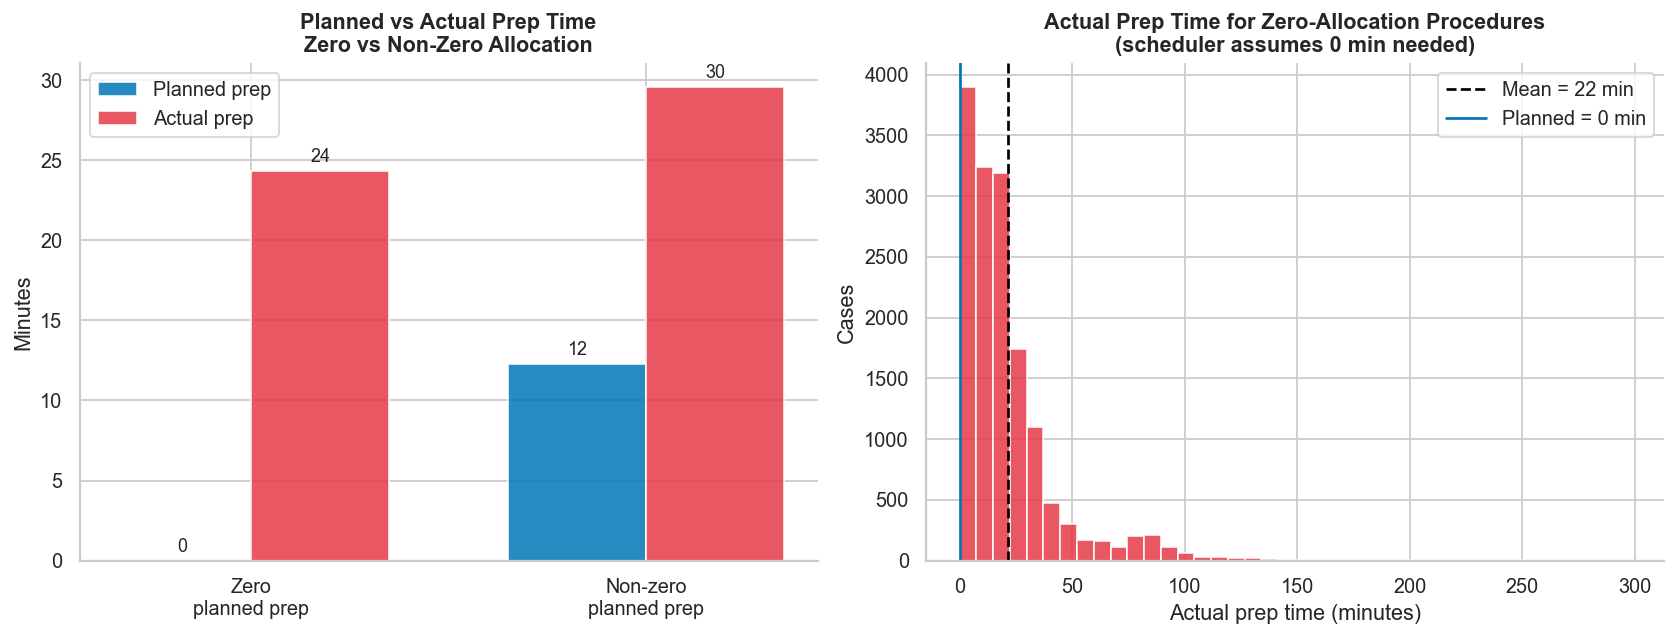

In [42]:
# Visual: zero vs non-zero allocation comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar comparison
ax = axes[0]
groups = ['Zero\nplanned prep', 'Non-zero\nplanned prep']
actual = [zero_alloc['actual_prep'].mean(), nonzero_alloc['actual_prep'].mean()]
planned = [0, nonzero_alloc['planned_prep'].mean()]

x = np.arange(2)
w = 0.35
ax.bar(x - w/2, planned, w, label='Planned prep', color=BLUE, alpha=0.85)
ax.bar(x + w/2, actual,  w, label='Actual prep',  color=RED,  alpha=0.85)
for i, (p, a) in enumerate(zip(planned, actual)):
    ax.text(i - w/2, p + 0.3, f'{p:.0f}', ha='center', va='bottom', fontsize=10)
    ax.text(i + w/2, a + 0.3, f'{a:.0f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylabel('Minutes')
ax.set_title('Planned vs Actual Prep Time\nZero vs Non-Zero Allocation', fontweight='bold')
ax.legend()

# Right: distribution of actual prep for zero-allocation procedures
ax = axes[1]
za_pd = valid.filter(
    pl.col('procedure_name').is_in(zero_alloc['procedure_name'].to_list())
)['actual_prep_min'].drop_nulls().to_pandas()
ax.hist(za_pd, bins=40, color=RED, alpha=0.85, edgecolor='white')
ax.axvline(za_pd.mean(), color='black', lw=1.5, ls='--',
           label=f'Mean = {za_pd.mean():.0f} min')
ax.axvline(0, color=BLUE, lw=1.5, ls='-', label='Planned = 0 min')
ax.set_xlabel('Actual prep time (minutes)')
ax.set_ylabel('Cases')
ax.set_title('Actual Prep Time for Zero-Allocation Procedures\n'
             '(scheduler assumes 0 min needed)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.show()

---
## 3. Three types of OR days

When the first case starts late, three outcomes are possible:

- **Cascading** — delay grows with each case through the day. The initial shock compounds.
- **One-time shock** — delay is inherited by later cases but does not grow further.
- **Recovery** — despite a late start, the team recovers and the day ends nearly on time.

We classify each OR-day by the correlation between case position and start delay within that day.

In [43]:
# Classify OR-days
day_patterns = (
    valid
    .sort(['or_room', 'date', 'ts_patient_in_or_planned'])
    .with_columns(
        pl.col('ts_patient_in_or_planned')
        .rank('ordinal').over(['or_room', 'date'])
        .alias('position'),
        pl.col('ts_patient_in_or_planned')
        .count().over(['or_room', 'date'])
        .alias('total_cases_that_day')
    )
    .filter(pl.col('total_cases_that_day') >= 3)
)

day_corr = (
    day_patterns
    .group_by(['or_room', 'date'])
    .agg([
        pl.corr('position', 'start_delay_min', method='pearson').alias('position_delay_corr'),
        pl.col('start_delay_min').first().alias('first_case_delay'),
        pl.col('prep_gap').first().alias('first_case_prep_gap'),
        pl.col('start_delay_min').mean().alias('mean_day_delay'),
        pl.col('finish_delay_min').last().alias('last_case_finish_delay'),
        pl.col('total_cases_that_day').first().alias('n_cases'),
        pl.col('specialty').first().alias('specialty'),
    ])
    .drop_nulls()
    .with_columns(
        pl.when(pl.col('position_delay_corr') > 0.5).then(pl.lit('Cascading'))
        .when(pl.col('position_delay_corr') < -0.2).then(pl.lit('Recovery'))
        .otherwise(pl.lit('One-time shock'))
        .alias('day_type')
    )
)

summary = (
    day_corr
    .group_by('day_type')
    .agg([
        pl.len().alias('n_days'),
        pl.col('first_case_delay').mean().round(1).alias('mean_first_delay'),
        pl.col('first_case_prep_gap').mean().round(1).alias('mean_first_prep_gap'),
        pl.col('mean_day_delay').mean().round(1).alias('mean_day_delay'),
        pl.col('last_case_finish_delay').mean().round(1).alias('mean_last_finish_delay'),
    ])
    .sort('n_days', descending=True)
)
summary

day_type,n_days,mean_first_delay,mean_first_prep_gap,mean_day_delay,mean_last_finish_delay
str,u32,f64,f64,f64,f64
"""Cascading""",1096,11.8,26.1,34.7,62.0
"""Recovery""",997,19.6,29.2,3.4,-17.1
"""One-time shock""",564,14.5,26.2,17.7,23.6


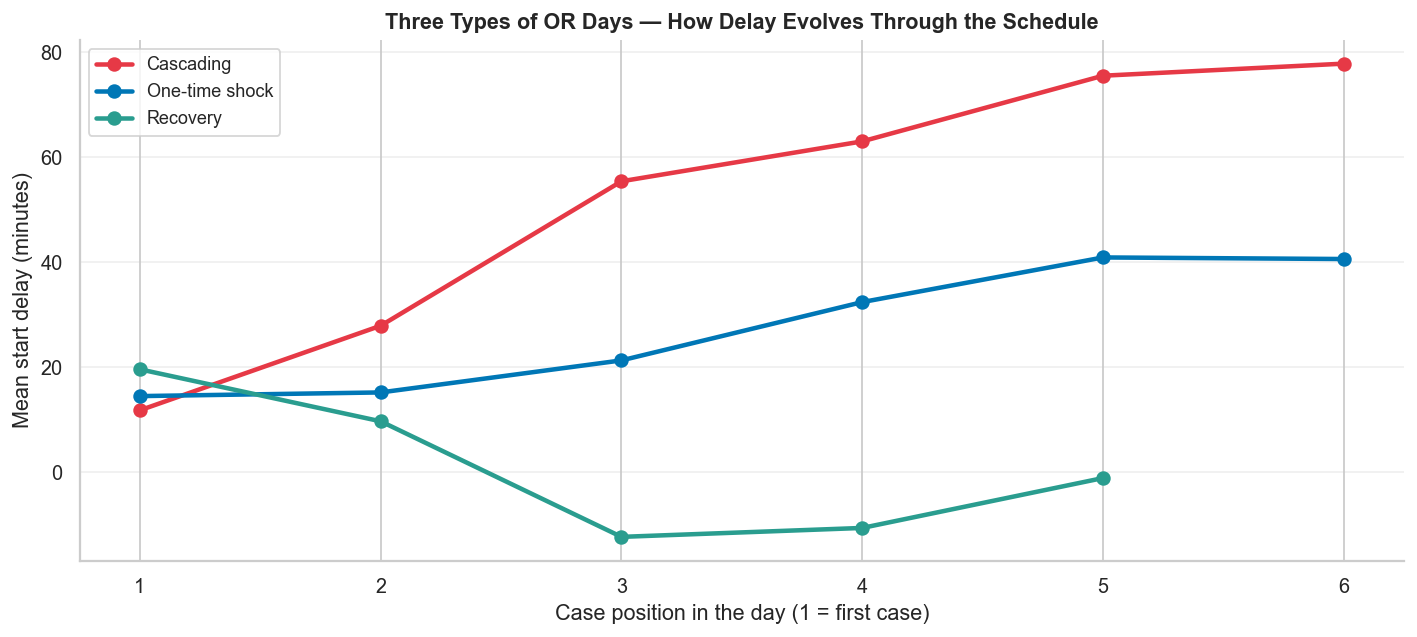

In [44]:
# Position trend by day type
position_by_type = (
    day_patterns
    .join(day_corr.select(['or_room', 'date', 'day_type']), on=['or_room', 'date'])
    .group_by(['day_type', 'position'])
    .agg([
        pl.col('start_delay_min').mean().round(1).alias('mean_delay'),
        pl.len().alias('n'),
    ])
    .filter(pl.col('n') >= 30)
    .sort(['day_type', 'position'])
    .to_pandas()
)

colors_map = {'Cascading': RED, 'One-time shock': BLUE, 'Recovery': GREEN}

fig, ax = plt.subplots(figsize=(11, 5))
for day_type, group in position_by_type.groupby('day_type'):
    ax.plot(group['position'], group['mean_delay'], 'o-',
            color=colors_map[day_type], label=day_type, linewidth=2.5, markersize=7)

ax.set_xlabel('Case position in the day (1 = first case)')
ax.set_ylabel('Mean start delay (minutes)')
ax.set_title('Three Types of OR Days — How Delay Evolves Through the Schedule',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'E', dpi=150, bbox_inches='tight')
plt.show()

### Best-case examples of each day type

The most illustrative example of each type — a single real OR day from the data.

In [45]:
def get_best_example(day_type, day_corr, day_patterns, min_cases=4):
    """Find the most illustrative OR-day for a given type."""
    candidates = (
        day_corr
        .filter(
            (pl.col('day_type') == day_type) &
            (pl.col('n_cases') >= min_cases)
        )
    )
    if day_type == 'Cascading':
        # Highest correlation + meaningful first delay
        best = candidates.sort('position_delay_corr', descending=True).head(1)
    elif day_type == 'Recovery':
        # Lowest correlation (most negative) + high first delay
        best = candidates.sort('position_delay_corr').head(1)
    else:
        # One-time shock: correlation near 0, meaningful first delay
        best = (
            candidates
            .with_columns(pl.col('position_delay_corr').abs().alias('abs_corr'))
            .sort('abs_corr')
            .head(1)
        )

    room = best['or_room'][0]
    date = best['date'][0]

    day_data = (
        day_patterns
        .filter((pl.col('or_room') == room) & (pl.col('date') == date))
        .sort('position')
        .to_pandas()
    )
    return room, date, day_data

examples = {}
for dt in ['Cascading', 'One-time shock', 'Recovery']:
    room, date, data = get_best_example(dt, day_corr, day_patterns)
    examples[dt] = (room, date, data)
    print(f'{dt}: OR {room} on {date} ({len(data)} cases)')

Cascading: OR GLO Ø 36 STUE 04 on 2024-02-19 (4 cases)
One-time shock: OR GLO Ø 46 STUE 11 on 2025-08-26 (8 cases)
Recovery: OR RH DAGKIR D (H) on 2025-06-30 (4 cases)


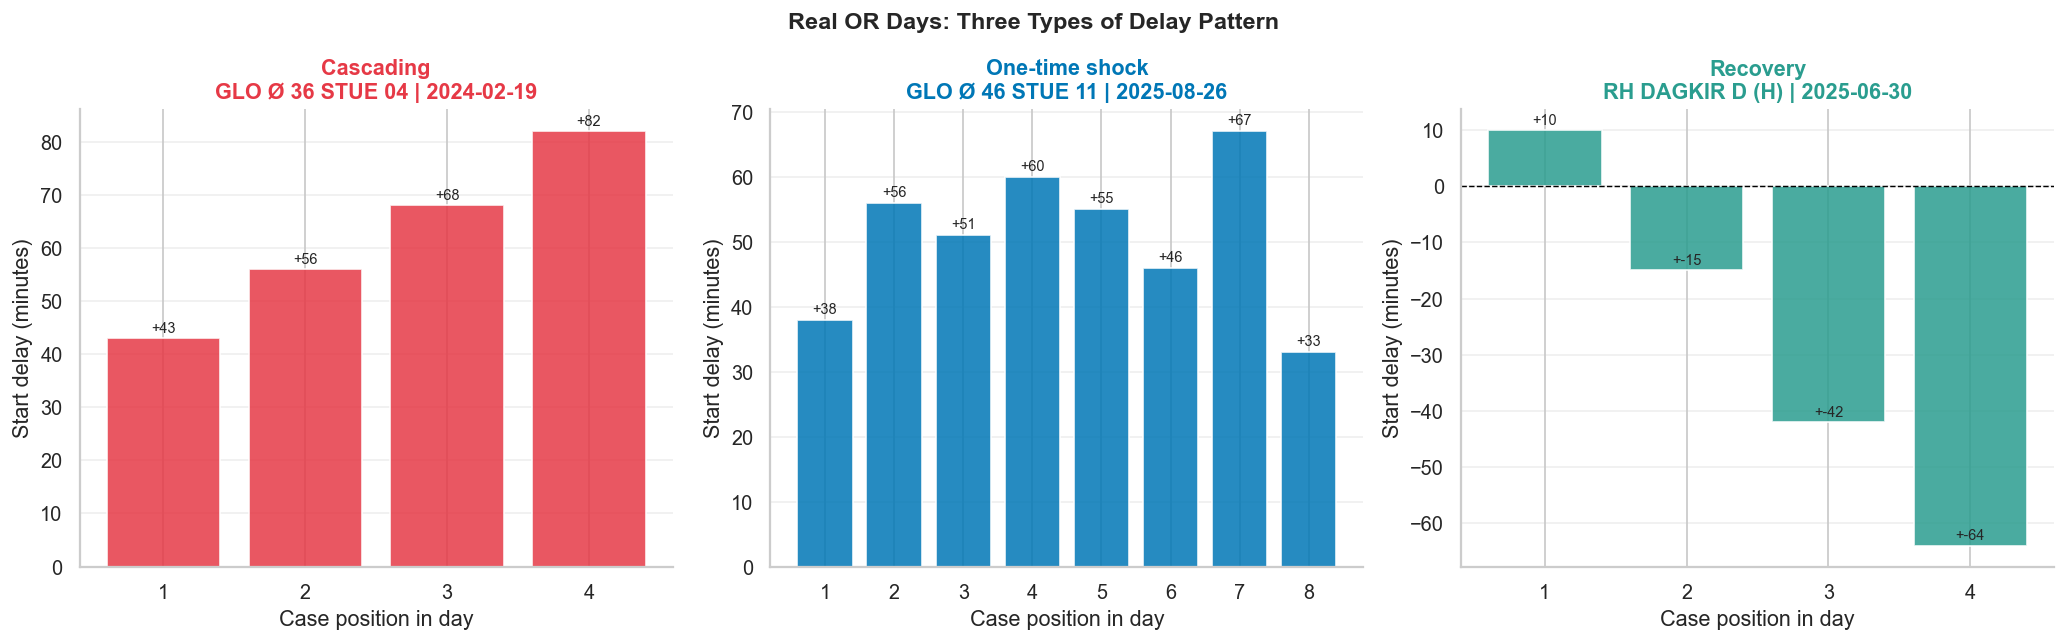

In [46]:
# Visual: three example days side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, (day_type, (room, date, data)) in zip(axes, examples.items()):
    color = colors_map[day_type]

    ax.bar(data['position'], data['start_delay_min'],
           color=color, alpha=0.85, edgecolor='white')
    ax.axhline(0, color='black', lw=0.8, ls='--')

    # Annotate each bar
    for _, row in data.iterrows():
        ax.text(row['position'], row['start_delay_min'] + 0.5,
                f"+{row['start_delay_min']:.0f}",
                ha='center', va='bottom', fontsize=8)

    ax.set_xlabel('Case position in day')
    ax.set_ylabel('Start delay (minutes)')
    ax.set_title(f'{day_type}\n{room} | {date}', fontweight='bold', color=color)
    ax.set_xticks(data['position'])
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Real OR Days: Three Types of Delay Pattern', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

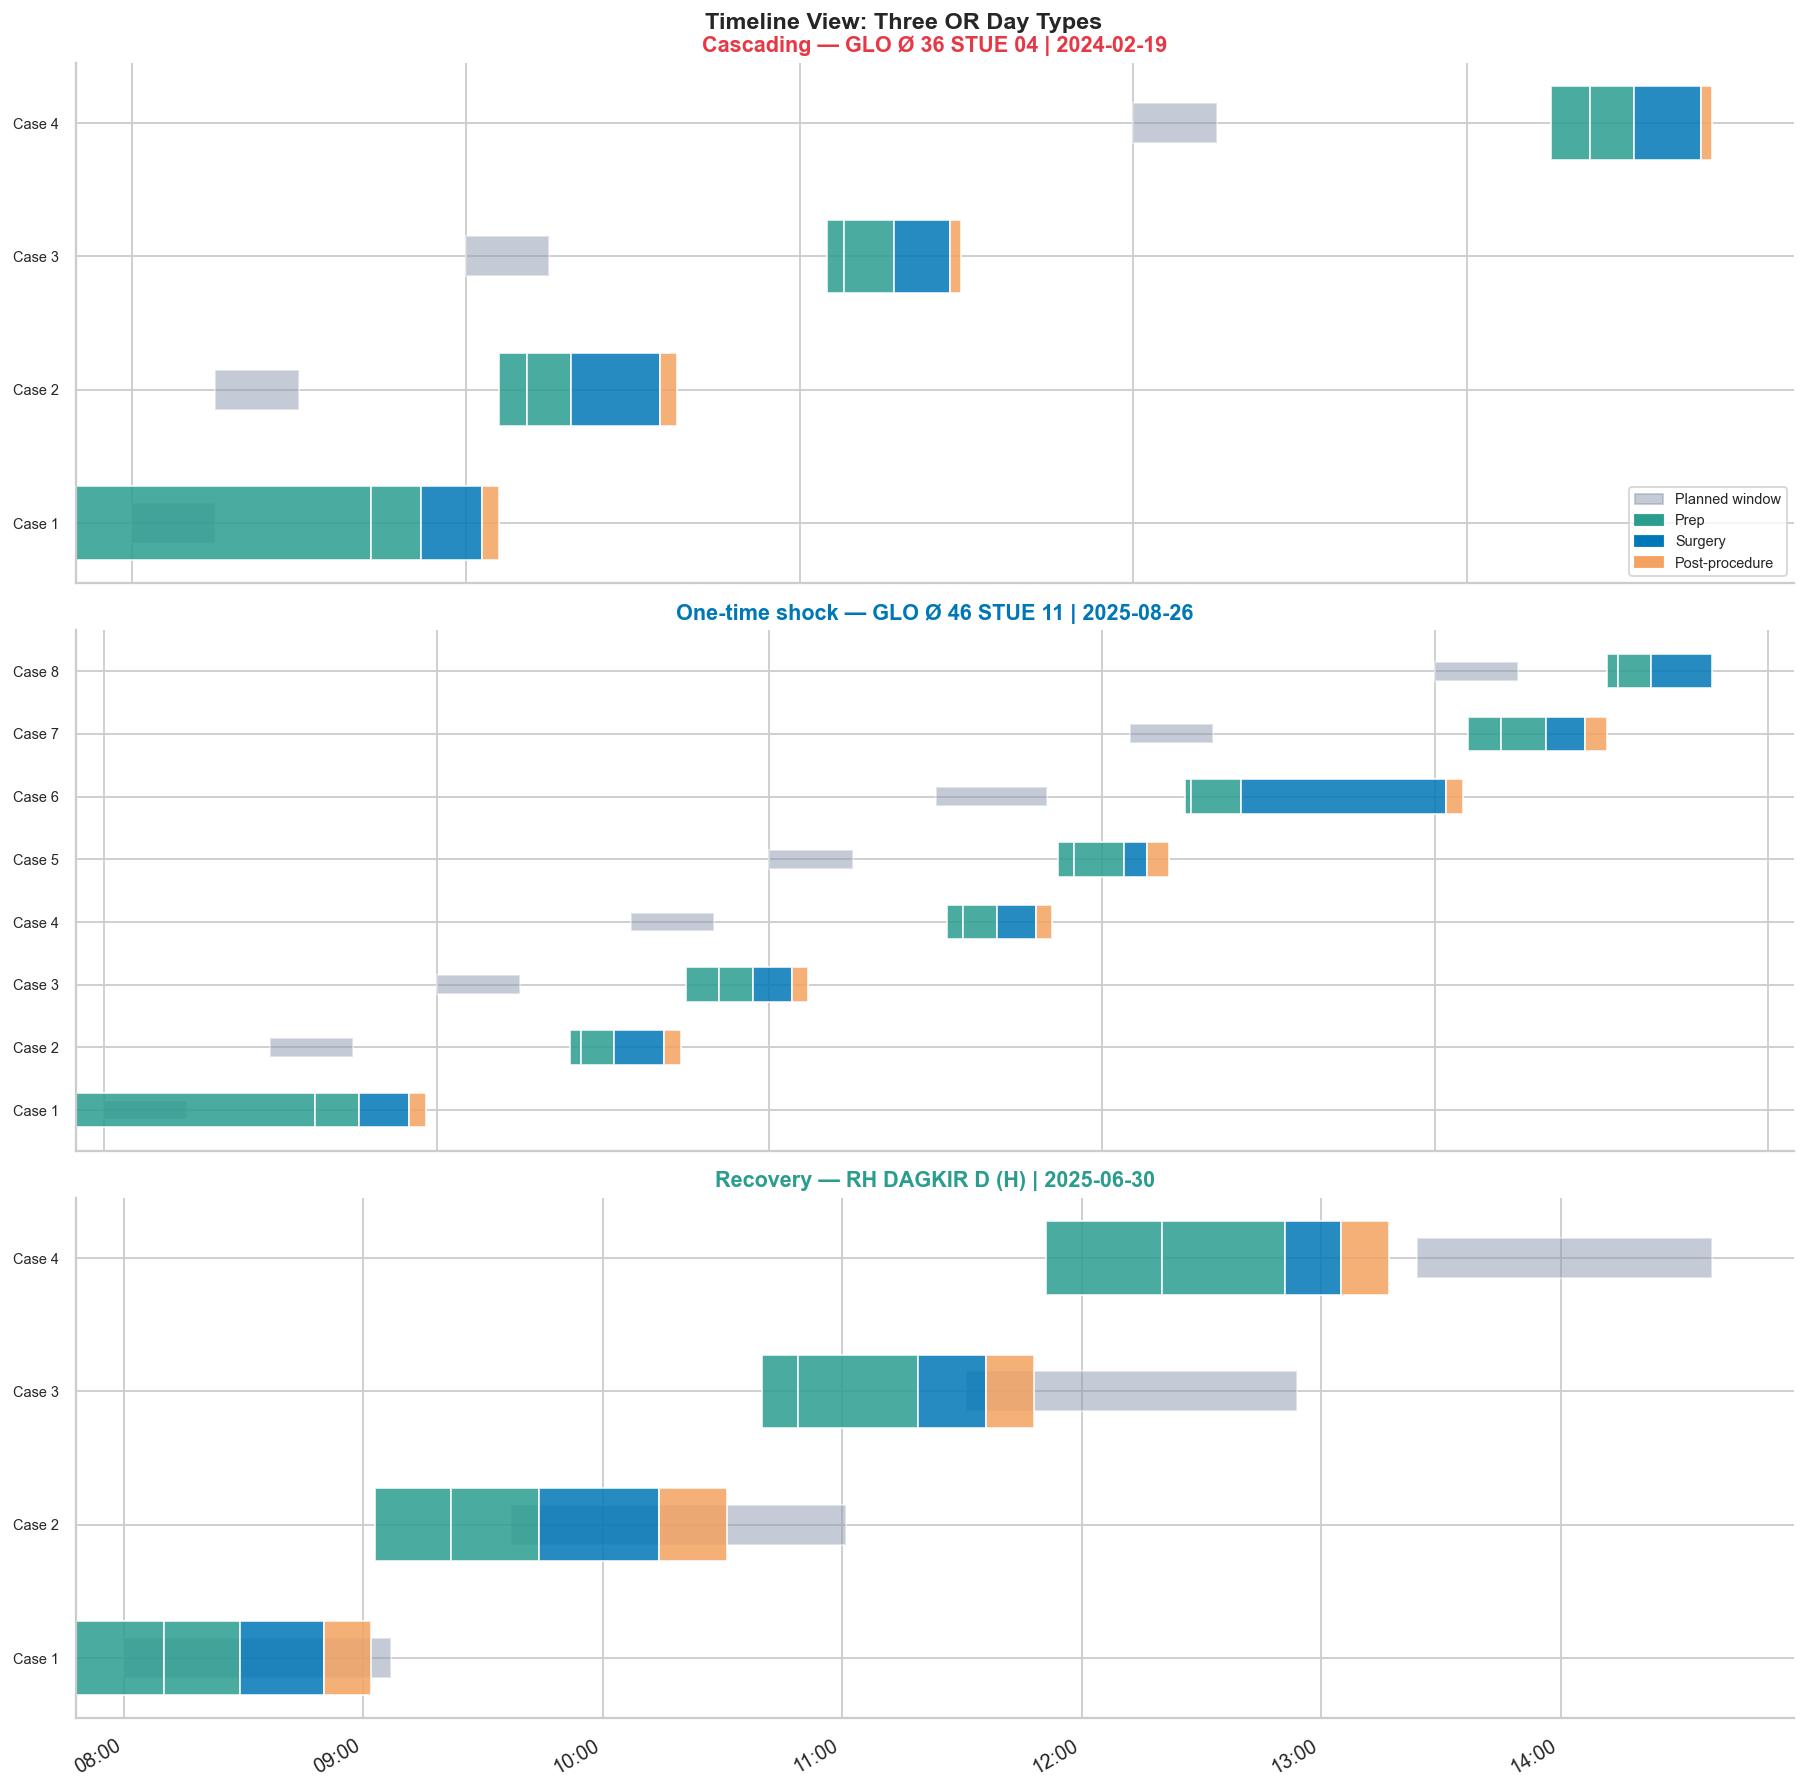

In [47]:
# Dotted chart: full timeline for each example day
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

PHASE_COLORS = {'prep': GREEN, 'surgery': BLUE, 'post': ORANGE}

for ax, (day_type, (room, date, data)) in zip(axes, examples.items()):
    # Get full case data with timestamps
    day_full = (
        valid
        .filter((pl.col('or_room') == room) & (pl.col('date') == date))
        .sort('ts_patient_in_or_planned')
        .to_pandas()
    )

    for i, (_, row) in enumerate(day_full.iterrows()):
        # Planned block
        p0 = row.get('ts_patient_in_or_planned')
        p1 = row.get('ts_patient_leaves_or_planned')
        if pd.notna(p0) and pd.notna(p1):
            ax.barh(i, mdates.date2num(p1) - mdates.date2num(p0),
                    left=mdates.date2num(p0), height=0.3,
                    color=GREY, alpha=0.5)

        # Actual phases
        for t0c, t1c, color in [
            ('ts_or_prep_start', 'ts_patient_in_or', PHASE_COLORS['prep']),
            ('ts_patient_in_or', 'ts_procedure_start', PHASE_COLORS['prep']),
            ('ts_procedure_start', 'ts_procedure_end', PHASE_COLORS['surgery']),
            ('ts_procedure_end', 'ts_patient_leaves_or', PHASE_COLORS['post']),
        ]:
            t0, t1 = row.get(t0c), row.get(t1c)
            if pd.notna(t0) and pd.notna(t1) and t1 > t0:
                ax.barh(i, mdates.date2num(t1) - mdates.date2num(t0),
                        left=mdates.date2num(t0), height=0.55,
                        color=color, alpha=0.85)

    ax.set_yticks(range(len(day_full)))
    ax.set_yticklabels([f'Case {i+1}' for i in range(len(day_full))], fontsize=8)
    ax.xaxis_date()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    fig.autofmt_xdate()
    ax.set_title(f'{day_type} — {room} | {date}',
                 fontweight='bold', color=colors_map[day_type])

legend_patches = [
    mpatches.Patch(color=GREY,  alpha=0.5, label='Planned window'),
    mpatches.Patch(color=GREEN, label='Prep'),
    mpatches.Patch(color=BLUE,  label='Surgery'),
    mpatches.Patch(color=ORANGE,label='Post-procedure'),
]
axes[0].legend(handles=legend_patches, loc='lower right', fontsize=8)
plt.suptitle('Timeline View: Three OR Day Types', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. We can do better — complexity predicts prep time

The correction table fixes the known gap for historical procedures. But there is a deeper opportunity:
**prep time is predictable from information the scheduler already has before the patient enters the room.**

Staff requirements and equipment needs are known at scheduling time. A simple model using these inputs — plus procedure type — could predict required prep time and automatically set correct allocations, including for new or rare procedures without enough history for a lookup table.

In [ ]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Procedure-level aggregation ───────────────────────────────────────────────
proc_causal_ext = (
    valid_with_pos  # use the version with position features
    .group_by('procedure_name')
    .agg([
        pl.len().alias('n'),
        pl.col('prep_gap').mean().alias('prep_gap_mean'),
        pl.col('actual_prep_min').mean().alias('actual_prep_mean'),
        pl.col('planned_prep_min').mean().alias('planned_prep_mean'),
        pl.col('staff_count').mean().alias('mean_staff'),
        pl.col('resource_count').mean().alias('mean_resources'),
        pl.col('has_anesthesia').cast(pl.Float64).mean().alias('pct_anesthesia'),
        pl.col('patient_age').mean().alias('mean_age'),
        pl.col('is_first_of_day').cast(pl.Float64).mean().alias('pct_first_of_day'),
        pl.col('is_last_of_day').cast(pl.Float64).mean().alias('pct_last_of_day'),
        pl.col('position').mean().alias('mean_position'),
        pl.col('total_cases_that_day').mean().alias('mean_total_cases'),
    ])
    .filter(pl.col('n') >= MIN_N)
    .to_pandas()
)

core_predictors = {
    'Staff count':          'mean_staff',
    'Equipment count':      'mean_resources',
    '% with anesthesia':    'pct_anesthesia',
    '% first of day':       'pct_first_of_day',
    '% last of day':        'pct_last_of_day',
}

rows = []
for label, col in core_predictors.items():
    data = proc_causal_ext[
        [col, 'prep_gap_mean', 'actual_prep_mean', 'planned_prep_mean']
    ].dropna()
    if data[col].std() < 0.01:
        continue
    r_actual = data[col].corr(data['actual_prep_mean'])
    r_sched  = data[col].corr(data['planned_prep_mean'])
    rows.append({
        'predictor':                   label,
        'r → actual prep time':        round(r_actual, 3),
        'r → planned prep (schedule)': round(r_sched, 3),
        'schedule gap':                round(r_actual - r_sched, 3),
    })

signal_df = (
    pd.DataFrame(rows)
    .sort_values('r → actual prep time', ascending=False)
    .reset_index(drop=True)
)

print('How well do schedulable inputs predict actual prep time?')
print('(schedule gap = signal the scheduler is missing)')
print()
signal_df


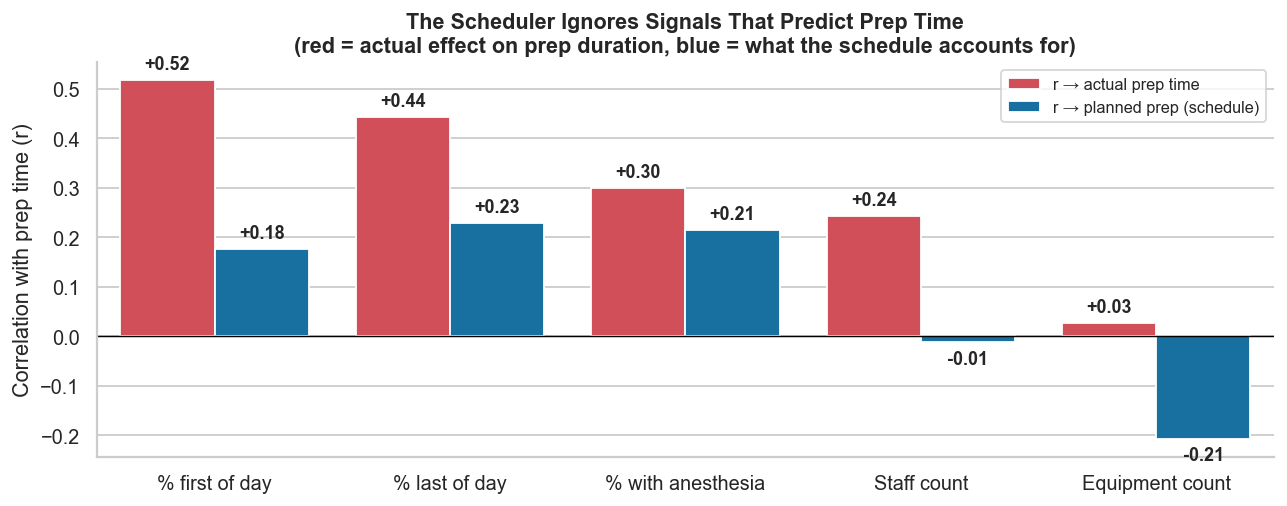

In [61]:
# Visual
plot_df = signal_df.melt(
    id_vars='predictor',
    value_vars=['r → actual prep time', 'r → planned prep (schedule)'],
    var_name='Metric',
    value_name='r'
)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=plot_df, x='predictor', y='r', hue='Metric',
            palette=[RED, BLUE], edgecolor='white', ax=ax)

for p in ax.patches:
    h = p.get_height()
    if abs(h) < 0.001:
        continue
    ax.annotate(f'{h:+.2f}',
                (p.get_x() + p.get_width()/2, h),
                ha='center',
                va='bottom' if h >= 0 else 'top',
                fontsize=10, fontweight='bold',
                xytext=(0, 4 if h >= 0 else -4),
                textcoords='offset points')

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Correlation with prep time (r)')
ax.set_xlabel('')
ax.set_title(
    'The Scheduler Ignores Signals That Predict Prep Time\n'
    '(red = actual effect on prep duration, blue = what the schedule accounts for)',
    fontweight='bold'
)
ax.legend(title='', fontsize=9)
plt.tight_layout()
plt.show()

Train (2024): 19,054 cases
Test  (2025): 19,136 cases
=== 2025 Test Set Performance (no patient age) ===
                     MAE        R²
Current schedule:    23.2 min   -0.703
Model prediction:    16.3 min   +0.019

Model reduces MAE by 6.9 min per case
Mean gap — current schedule: +22.3 min
Mean gap — model prediction: -1.0 min

First-of-day vs later cases:
          actual_prep_min  predicted_prep  planned_prep_min
is_first                                                   
False                16.8            18.1               3.2
True                 31.3            32.2               4.3



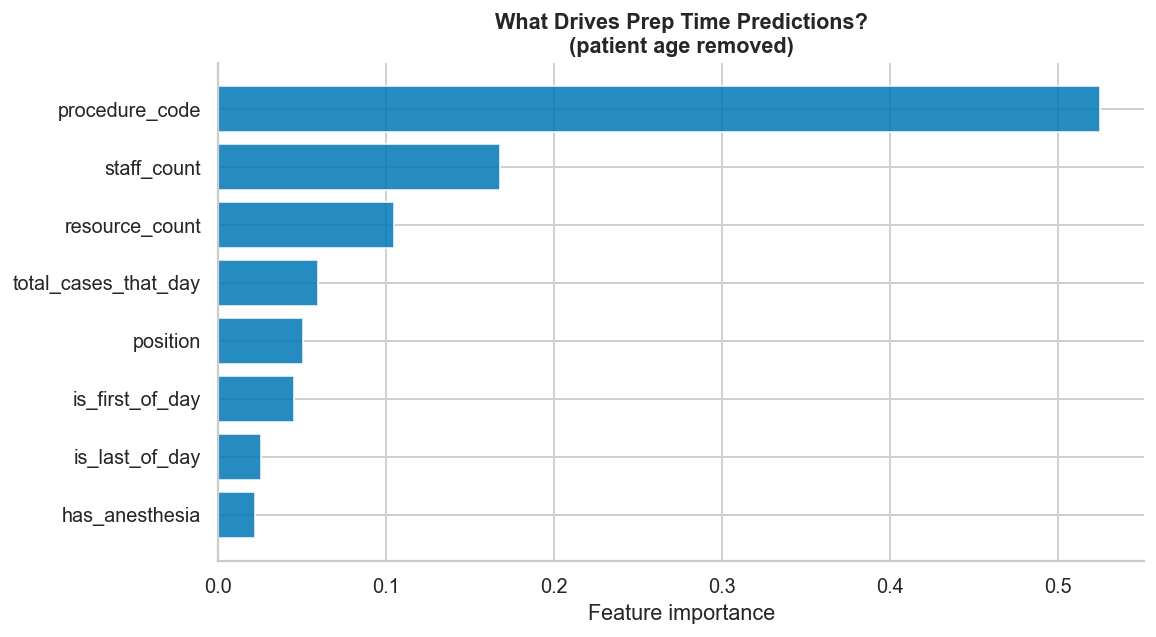

test_with_meta ready: 19,136 cases


In [51]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# ── Add position features ─────────────────────────────────────────────────────
valid_with_pos = (
    valid
    .sort(['or_room', 'date', 'ts_patient_in_or_planned'])
    .with_columns([
        pl.col('ts_patient_in_or_planned')
        .rank('ordinal').over(['or_room', 'date'])
        .alias('position'),
        pl.col('ts_patient_in_or_planned')
        .count().over(['or_room', 'date'])
        .alias('total_cases_that_day'),
    ])
    .with_columns([
        (pl.col('position') == 1).alias('is_first_of_day'),
        (pl.col('position') == pl.col('total_cases_that_day')).alias('is_last_of_day'),
    ])
)

# ── Split by year ─────────────────────────────────────────────────────────────
valid_with_year = valid_with_pos.with_columns(
    pl.col('date').dt.year().alias('year')
)

train = valid_with_year.filter(pl.col('year') == 2024).to_pandas()
test  = valid_with_year.filter(pl.col('year') == 2025).to_pandas()

print(f'Train (2024): {len(train):,} cases')
print(f'Test  (2025): {len(test):,} cases')

# ── Encode procedure name ─────────────────────────────────────────────────────
# Build mapping from training set only — -1 = unseen procedure
proc_map = {p: i for i, p in enumerate(train['procedure_name'].dropna().unique())}
train['procedure_code'] = train['procedure_name'].map(proc_map).fillna(-1).astype(int)
test['procedure_code']  = test['procedure_name'].map(proc_map).fillna(-1).astype(int)


FEATURES = [
    'procedure_code',
    'staff_count',
    'resource_count',
    'has_anesthesia',
    'is_first_of_day',
    'is_last_of_day',
    'position',
    'total_cases_that_day',
]

train_clean = train[FEATURES + ['actual_prep_min']].dropna()
test_clean  = test[FEATURES + ['actual_prep_min', 'planned_prep_min', 'prep_gap']].dropna()

for col in ['has_anesthesia', 'is_first_of_day', 'is_last_of_day']:
    train_clean[col] = train_clean[col].astype(int)
    test_clean[col]  = test_clean[col].astype(int)

X_train = train_clean[FEATURES]
y_train = train_clean['actual_prep_min']
X_test  = test_clean[FEATURES]
y_test  = test_clean['actual_prep_min']

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

test_clean = test_clean.copy()
test_clean['predicted_prep'] = rf.predict(X_test)
test_clean['predicted_gap']  = test_clean['actual_prep_min'] - test_clean['predicted_prep']
test_clean['model_error']    = test_clean['predicted_gap'].abs()

mae_current = mean_absolute_error(y_test, test_clean['planned_prep_min'])
mae_model   = mean_absolute_error(y_test, test_clean['predicted_prep'])
r2_current  = r2_score(y_test, test_clean['planned_prep_min'])
r2_model    = r2_score(y_test, test_clean['predicted_prep'])

print('=== 2025 Test Set Performance (no patient age) ===')
print(f'                     MAE        R²')
print(f'Current schedule:   {mae_current:5.1f} min   {r2_current:+.3f}')
print(f'Model prediction:   {mae_model:5.1f} min   {r2_model:+.3f}')
print()
print(f'Model reduces MAE by {mae_current - mae_model:.1f} min per case')
print(f'Mean gap — current schedule: {test_clean["prep_gap"].mean():+.1f} min')
print(f'Mean gap — model prediction: {test_clean["predicted_gap"].mean():+.1f} min')
print()

# First-of-day vs later
test_clean['is_first'] = test_clean['is_first_of_day'].astype(bool)
print('First-of-day vs later cases:')
print(test_clean.groupby('is_first')[
    ['actual_prep_min', 'predicted_prep', 'planned_prep_min']
].mean().round(1))
print()

# Feature importance
importance = (
    pd.DataFrame({'feature': FEATURES, 'importance': rf.feature_importances_})
    .sort_values('importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance['feature'], importance['importance'],
        color=BLUE, alpha=0.85)
ax.set_xlabel('Feature importance')
ax.set_title('What Drives Prep Time Predictions?\n(patient age removed)', fontweight='bold')
plt.tight_layout()
plt.show()

# Rebuild test_with_meta
test_with_meta = test.copy()
test_with_meta = test_with_meta[test_with_meta.index.isin(test_clean.index)].copy()
test_with_meta['predicted_prep'] = test_clean['predicted_prep']
test_with_meta['model_error']    = test_clean['model_error']
test_with_meta['model_gap']      = test_clean['predicted_gap']

print(f'test_with_meta ready: {len(test_with_meta):,} cases')

In [52]:
(
    test[test['procedure_name'].map(
        lambda p: proc_map.get(p, -1)
    ) != -1]
    .groupby('procedure_name')
    .agg(
        n_test=('actual_prep_min', 'count'),
        mean_actual_prep=('actual_prep_min', 'mean'),
        mean_planned_prep=('planned_prep_min', 'mean'),
    )
    .round(1)
    .query('n_test >= 20')
    .sort_values('n_test', ascending=False)
    .head(20)
)

,n_test,mean_actual_prep,mean_planned_prep
procedure_name,,,
FAKO - LA BILATERAL,789,11.9,0.0
FAKO 3 - LA,439,8.1,0.0
CABG,307,55.8,20.0
FAKO 1 - LA,263,6.9,0.0
"AMOTIO, OPERATIV FJERNELSE AF TAND/ROD",226,21.5,0.6
TONSILLEKTOMI,213,16.1,0.0
AORTAKLAPPROTESE - VOKSEN,200,50.0,20.0
SECTIO ELEKTIV,196,25.8,15.0
KONKOTOMI/MILLERBRÆNDING,192,16.9,0.0


Procedure: CABG
Train cases (2024): 346
Test cases  (2025): 307

=== CABG — 2025 Test Performance ===
                        MAE
Current schedule:      36.3 min
General model:         25.3 min
Procedure model:       25.2 min

Mean actual prep:      55.8 min
Mean planned prep:     20.0 min
Mean general pred:     50.5 min
Mean procedure pred:   50.4 min



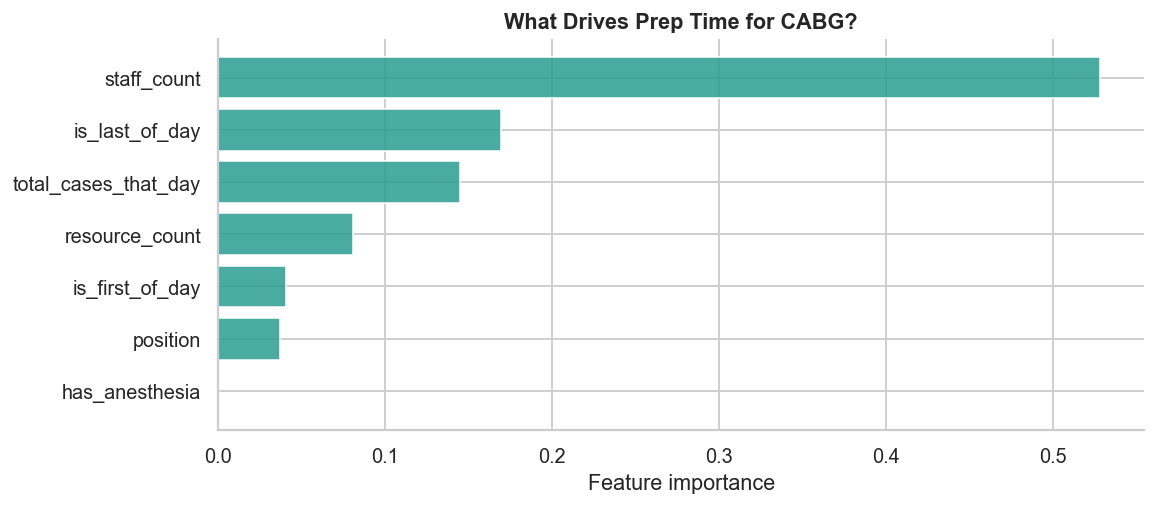

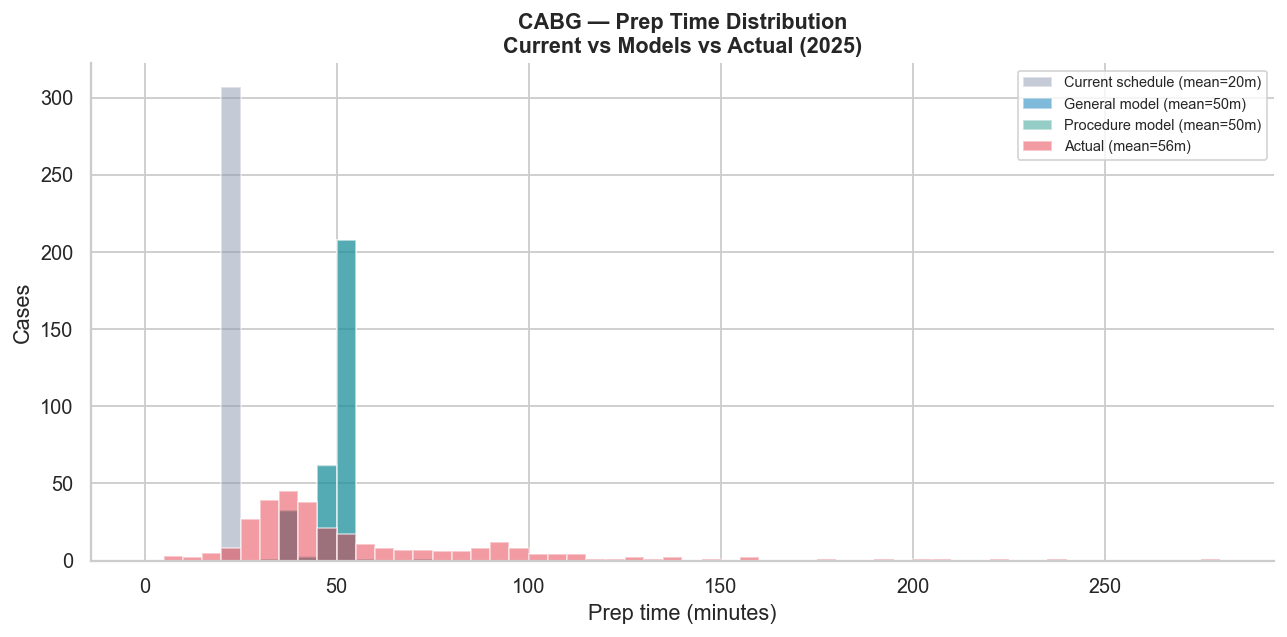

In [53]:
# ── Procedure-specific model ──────────────────────────────────────────────────
TARGET_PROCEDURE = 'CABG'  # change to any procedure

# Filter to this procedure only
train_proc = train[train['procedure_name'] == TARGET_PROCEDURE].copy()
test_proc  = test[test['procedure_name']  == TARGET_PROCEDURE].copy()

print(f'Procedure: {TARGET_PROCEDURE}')
print(f'Train cases (2024): {len(train_proc):,}')
print(f'Test cases  (2025): {len(test_proc):,}')
print()

if len(train_proc) < 50:
    print(f'Too few training cases (n={len(train_proc)}) — need at least 50')
else:
    # Use position/complexity features — procedure_code not needed (single procedure)
    PROC_FEATURES = [
        'staff_count',
        'resource_count',
        'has_anesthesia',
        'is_first_of_day',
        'is_last_of_day',
        'position',
        'total_cases_that_day',
    ]

    train_p = train_proc[PROC_FEATURES + ['actual_prep_min']].dropna()
    test_p  = test_proc[PROC_FEATURES + ['actual_prep_min', 'planned_prep_min', 'prep_gap']].dropna()

    for col in ['has_anesthesia', 'is_first_of_day', 'is_last_of_day']:
        train_p[col] = train_p[col].astype(int)
        test_p[col]  = test_p[col].astype(int)

    rf_proc = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_proc.fit(train_p[PROC_FEATURES], train_p['actual_prep_min'])

    test_p = test_p.copy()
    test_p['predicted_prep'] = rf_proc.predict(test_p[PROC_FEATURES])
    test_p['predicted_gap']  = test_p['actual_prep_min'] - test_p['predicted_prep']

    # General model predictions for same cases
    test_proc_general = test_proc[FEATURES + ['actual_prep_min', 'planned_prep_min', 'prep_gap']].dropna()
    for col in ['has_anesthesia', 'is_first_of_day', 'is_last_of_day']:
        test_proc_general[col] = test_proc_general[col].astype(int)
    test_proc_general['predicted_prep_general'] = rf.predict(test_proc_general[FEATURES])

    mae_sched   = mean_absolute_error(test_p['actual_prep_min'], test_p['planned_prep_min'])
    mae_general = mean_absolute_error(
        test_proc_general['actual_prep_min'],
        test_proc_general['predicted_prep_general']
    )
    mae_proc    = mean_absolute_error(test_p['actual_prep_min'], test_p['predicted_prep'])

    print(f'=== {TARGET_PROCEDURE} — 2025 Test Performance ===')
    print(f'                        MAE')
    print(f'Current schedule:      {mae_sched:.1f} min')
    print(f'General model:         {mae_general:.1f} min')
    print(f'Procedure model:       {mae_proc:.1f} min')
    print()
    print(f'Mean actual prep:      {test_p["actual_prep_min"].mean():.1f} min')
    print(f'Mean planned prep:     {test_p["planned_prep_min"].mean():.1f} min')
    print(f'Mean general pred:     {test_proc_general["predicted_prep_general"].mean():.1f} min')
    print(f'Mean procedure pred:   {test_p["predicted_prep"].mean():.1f} min')
    print()

    # Feature importance for this procedure
    imp_proc = (
        pd.DataFrame({'feature': PROC_FEATURES, 'importance': rf_proc.feature_importances_})
        .sort_values('importance', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(imp_proc['feature'], imp_proc['importance'], color=GREEN, alpha=0.85)
    ax.set_xlabel('Feature importance')
    ax.set_title(f'What Drives Prep Time for {TARGET_PROCEDURE}?', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Distribution: scheduled vs general model vs procedure model vs actual
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = range(0, int(test_p['actual_prep_min'].max()) + 10, 5)
    ax.hist(test_p['planned_prep_min'],  bins=bins, alpha=0.5, color=GREY,
            label=f'Current schedule (mean={test_p["planned_prep_min"].mean():.0f}m)')
    ax.hist(test_proc_general['predicted_prep_general'], bins=bins, alpha=0.5,
            color=BLUE, label=f'General model (mean={test_proc_general["predicted_prep_general"].mean():.0f}m)')
    ax.hist(test_p['predicted_prep'],    bins=bins, alpha=0.5, color=GREEN,
            label=f'Procedure model (mean={test_p["predicted_prep"].mean():.0f}m)')
    ax.hist(test_p['actual_prep_min'],   bins=bins, alpha=0.5, color=RED,
            label=f'Actual (mean={test_p["actual_prep_min"].mean():.0f}m)')
    ax.set_xlabel('Prep time (minutes)')
    ax.set_ylabel('Cases')
    ax.set_title(f'{TARGET_PROCEDURE} — Prep Time Distribution\nCurrent vs Models vs Actual (2025)',
                 fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [54]:
results_under20 = []

for (room, date), group in test_with_meta.groupby(['or_room', 'date']):
    group = group.sort_values('position')
    if len(group) < 2:
        continue

    delays = group['start_delay_min'].dropna().tolist()
    if len(delays) < 2:
        continue

    is_increasing = all(delays[i] < delays[i+1] for i in range(len(delays)-1))
    if not is_increasing:
        continue

    first = group[group['position'] == 1].iloc[0]
    if first['prep_gap'] < 15:
        continue
    if first['model_error'] > 20 or first['procedure_code'] == -1:
        continue
    if pd.isna(first['actual_prep_min']) or pd.isna(first['start_delay_min']):
        continue

    # Compute corrected delays for all cases
    group = group.copy()
    group['model_benefit'] = group.apply(
        lambda r: min(r['predicted_prep'], r['actual_prep_min']), axis=1
    )
    group['cumulative_benefit'] = group['model_benefit'].cumsum()
    group['corrected_start_delay'] = (
        group['start_delay_min'] - group['cumulative_benefit']
    ).clip(lower=0).round(1)

    # Key filter: all corrected delays under 20 min
    if group['corrected_start_delay'].max() > 20:
        continue

    # First case delay must be meaningful (>15 min) to tell a good story
    if first['start_delay_min'] < 15:
        continue

    results_under20.append({
        'or_room':          room,
        'date':             pd.Timestamp(date).date(),
        'n_cases':          len(group),
        'n_unique_procs':   group['procedure_name'].nunique(),
        'avg_model_error':  round(group['model_error'].mean(), 1),
        'procedures':       group['procedure_name'].tolist(),
        'delays':           delays,
        'planned_preps':    group['planned_prep_min'].tolist(),
        'predicted_preps':  group['predicted_prep'].tolist(),
        'actual_preps':     group['actual_prep_min'].tolist(),
        'corrected_delays': group['corrected_start_delay'].tolist(),
        'total_cascade':    delays[-1] - delays[0],
        'max_corrected':    group['corrected_start_delay'].max(),
    })

best_under20 = (
    pd.DataFrame(results_under20)
    .sort_values(['n_unique_procs', 'total_cascade'], ascending=[False, False])
    .head(10)
)

print(f'Candidates found: {len(results_under20)}')
print()
for _, r in best_under20.iterrows():
    print(f"{r['or_room']} | {r['date']} | {r['n_cases']} cases | "
          f"model error: {r['avg_model_error']} min | "
          f"cascade: +{r['total_cascade']:.0f} min | "
          f"max corrected: {r['max_corrected']:.0f} min")
    for p, d, planned_val, pr, ac, cd in zip(
        r['procedures'], r['delays'],
        r['planned_preps'], r['predicted_preps'],
        r['actual_preps'], r['corrected_delays']
    ):
        print(f"  {str(p)[:35]:35s} delay={d:+.0f} | "
              f"planned={planned_val:.0f} predicted={pr:.0f} "
              f"actual={ac:.0f} | corrected={cd:+.0f}")
    print()

Candidates found: 144

JMC 07 | 2025-05-12 | 4 cases | model error: 10.6 min | cascade: +66 min | max corrected: 19 min
  CYSTOSKOPI                          delay=+31 | planned=0 predicted=48 actual=46 | corrected=+0
  TRANSLUMINAL INJEKTION I BLÆREVÆG   delay=+71 | planned=0 predicted=21 actual=14 | corrected=+11
  OPERATION PÅ SCROTALINDHOLD         delay=+80 | planned=0 predicted=26 actual=9 | corrected=+11
  CYSTOSKOPI                          delay=+97 | planned=0 predicted=9 actual=26 | corrected=+19

RH DAGKIR E (H) | 2025-06-06 | 3 cases | model error: 13.4 min | cascade: +59 min | max corrected: 4 min
  SPRINGFINGER                        delay=+15 | planned=0 predicted=36 actual=30 | corrected=+0
  DEKOMPRESSION NERVE HÅND            delay=+37 | planned=0 predicted=21 actual=29 | corrected=+0
  GANGLION                            delay=+74 | planned=10 predicted=20 actual=46 | corrected=+4

JMC 07 | 2025-04-28 | 4 cases | model error: 7.2 min | cascade: +56 min | max correct

In [55]:
import polars as pl
import datetime

ROOM     = 'JMC 07'
DAY_DATE = datetime.date(2025, 4, 28)

day_cases = (
    valid_with_pos
    .filter((pl.col('or_room') == ROOM) & (pl.col('date') == DAY_DATE))
    .sort('ts_patient_in_or_planned')
    .to_pandas()
)

# Model predictions for all cases
day_cases['procedure_code'] = day_cases['procedure_name'].map(
    lambda p: proc_map.get(p, -1)
)
day_features = day_cases[FEATURES].copy()
for col in ['has_anesthesia', 'is_first_of_day', 'is_last_of_day']:
    day_features[col] = day_features[col].astype(int)

day_cases['predicted_prep'] = rf.predict(day_features.fillna(0))

# Corrected delays
day_cases['model_benefit'] = day_cases.apply(
    lambda r: min(r['predicted_prep'], r['actual_prep_min']), axis=1
)
day_cases['cumulative_benefit'] = day_cases['model_benefit'].cumsum()
day_cases['corrected_start_delay'] = (
    day_cases['start_delay_min'] - day_cases['cumulative_benefit']
).clip(lower=0).round(1)

print(f'OR Room: {ROOM}  |  Date: {DAY_DATE}')
print()
day_cases[[
    'position', 'procedure_name',
    'planned_prep_min', 'predicted_prep', 'actual_prep_min',
    'start_delay_min', 'corrected_start_delay'
]].round(1)

OR Room: JMC 07  |  Date: 2025-04-28



,position,procedure_name,planned_prep_min,predicted_prep,actual_prep_min,start_delay_min,corrected_start_delay
0,1,CYSTOSKOPI,0,32.6,39,24,0.0
1,2,HERNIOTOMI,0,17.2,31,40,0.0
2,3,CYSTOSKOPI,0,15.1,20,56,0.0
3,4,"BOTOX INJEKTION, BLÆREN",0,21.8,18,80,0.0


In [56]:
def compute_starts(alloc_preps, pinors, actual_preps, actual_inors, delays_ignored=None):
    """
    Compute allocated and actual start times sequentially.
    Each case starts when the previous one actually finishes.
    """
    alloc_starts  = []
    actual_starts = []

    alloc_t  = 0
    actual_t = 0

    for ap, pi, acp, ai in zip(alloc_preps, pinors, actual_preps, actual_inors):
        alloc_starts.append(alloc_t)
        actual_starts.append(actual_t)

        alloc_t  += max(ap, 0) + pi          # next alloc starts after this alloc ends
        actual_t += (acp or 0) + (ai or INOR_DUR)  # next actual starts after this actual ends

    return alloc_starts, actual_starts

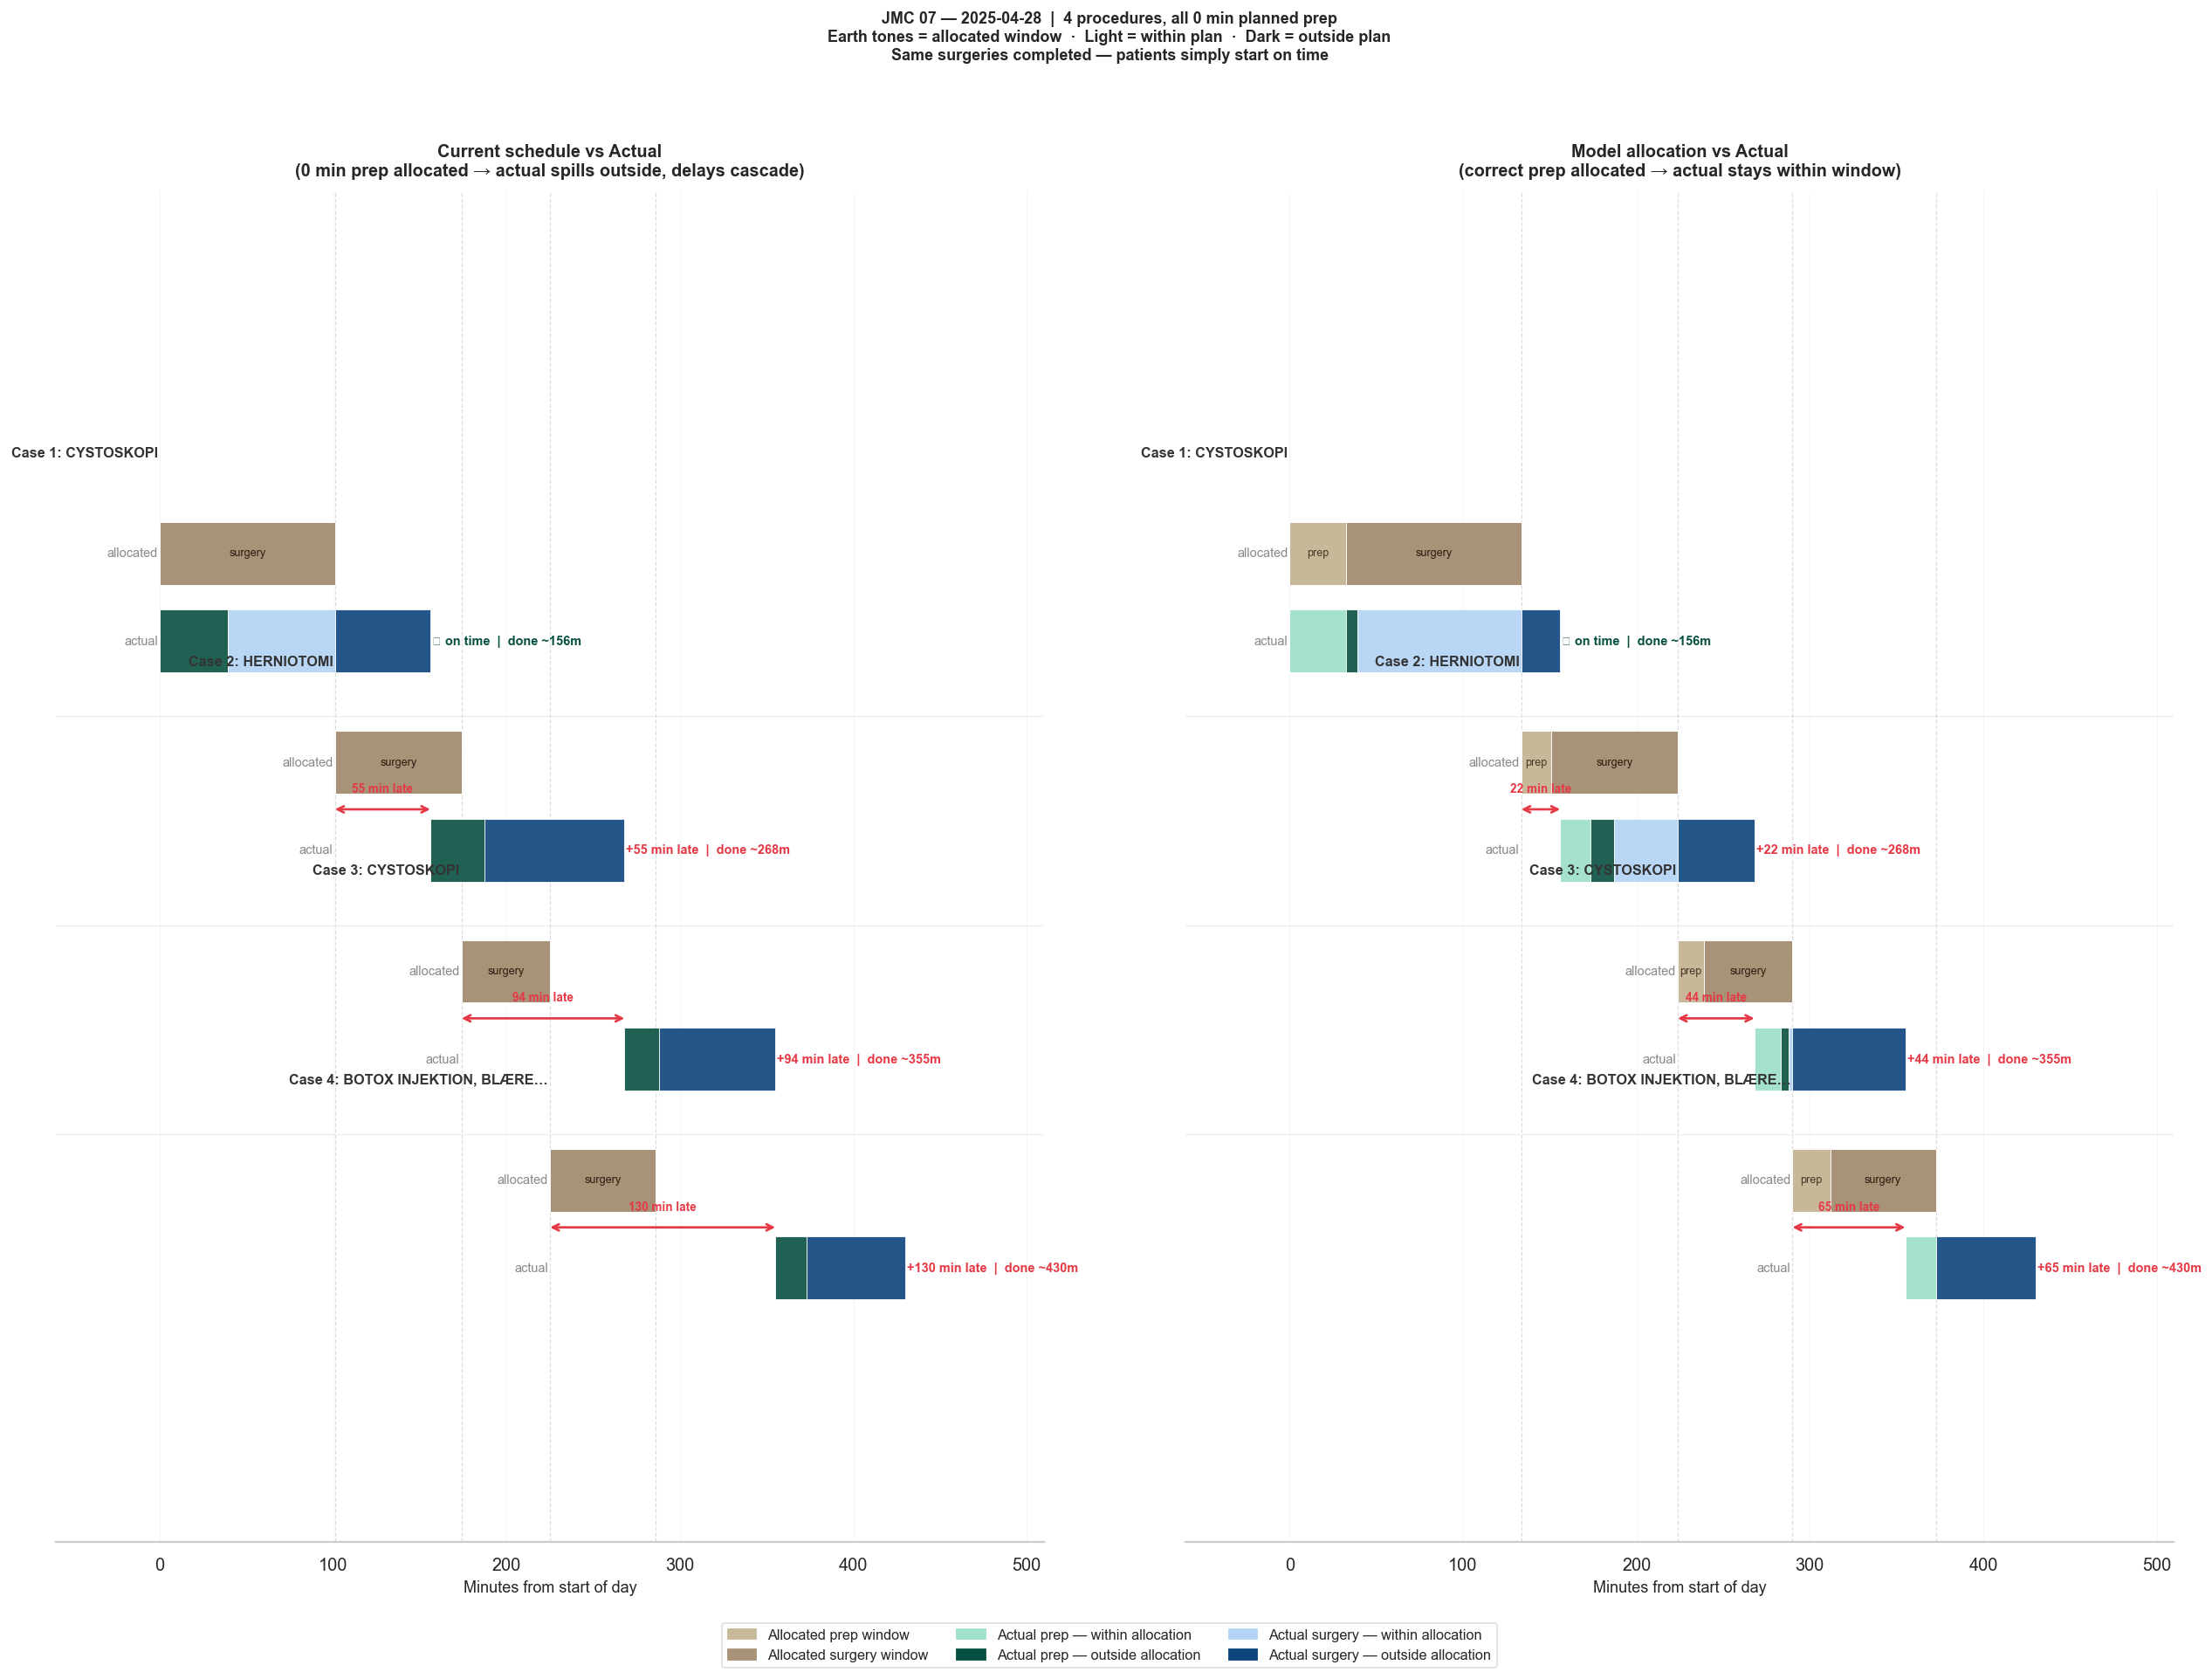

In [57]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

cases        = [p[:22] + '…' if len(p) > 22 else p
                for p in day_cases['procedure_name'].tolist()]
delays       = day_cases['start_delay_min'].tolist()
corrected    = day_cases['corrected_start_delay'].tolist()
predicted    = day_cases['predicted_prep'].tolist()
actual_prep  = day_cases['actual_prep_min'].tolist()
planned_prep = day_cases['planned_prep_min'].tolist()
planned_inor = day_cases['planned_inor_min'].tolist()
actual_inor  = day_cases['actual_inor_min'].tolist()

n        = len(cases)
INOR_DUR = 35

# ── Color scheme ──────────────────────────────────────────────────────────────
COL_ALLOC_PREP   = '#C8B89A'   # warm sand    — allocated prep window
COL_ALLOC_INOR   = '#A89278'   # darker earth — allocated surgery window
COL_PREP_WITHIN  = '#9FE1CB'   # light green  — prep within allocation
COL_PREP_OUTSIDE = '#085041'   # dark green   — prep outside allocation
COL_INOR_WITHIN  = '#B5D4F4'   # light blue   — surgery within allocation
COL_INOR_OUTSIDE = '#0C447C'   # dark blue    — surgery outside allocation
COL_ARROW        = '#E63946'   # red arrow

ROW_H = 0.30
GAP   = 1.0

def compute_starts(alloc_preps, pinors, act_preps, act_inors):
    """
    Compute sequential allocated and actual start times independently.
    Each case starts when the previous one finishes — no fixed spacing.
    """
    alloc_starts  = []
    actual_starts = []
    alloc_t  = 0
    actual_t = 0
    for ap, pi, acp, ai in zip(alloc_preps, pinors, act_preps, act_inors):
        alloc_starts.append(alloc_t)
        actual_starts.append(actual_t)
        alloc_t  += max(ap, 0) + pi
        actual_t += (acp if acp and acp > 0 else 0) + (ai if ai and ai > 0 else INOR_DUR)
    return alloc_starts, actual_starts

def draw_plot(ax, title, use_model=False):

    alloc_preps = [p if use_model else max(planned_prep[i], 0)
                   for i, p in enumerate(predicted)]
    pinors      = [pi if pi and pi > 0 else INOR_DUR for pi in planned_inor]
    act_inors   = [ai if ai and ai > 0 else INOR_DUR for ai in actual_inor]

    alloc_starts, actual_starts = compute_starts(
        alloc_preps, pinors, actual_prep, act_inors
    )

    for i, (name, pred, act) in enumerate(zip(cases, predicted, actual_prep)):

        y     = (n - 1 - i) * GAP
        pinor = pinors[i]
        ainor = act_inors[i]

        ap           = alloc_preps[i]
        alloc_start  = alloc_starts[i]
        actual_start = actual_starts[i]

        alloc_prep_end = alloc_start + max(ap, 0)
        alloc_end      = alloc_prep_end + pinor
        delay_gap      = actual_start - alloc_start

        # ── Row 1: Allocated windows (earth tones) ────────────────────────────
        y1 = y + ROW_H * 0.7

        # Allocated prep
        if ap > 0:
            ax.barh(y1, ap, left=alloc_start,
                    height=ROW_H, color=COL_ALLOC_PREP,
                    linewidth=0.5, edgecolor='white')
            if ap > 8:
                ax.text(alloc_start + ap/2, y1, 'prep',
                        va='center', ha='center', fontsize=7,
                        color='#4A3728', fontweight='500')
        else:
            ax.barh(y1, 0.8, left=alloc_start, height=ROW_H,
                    color=COL_ALLOC_PREP, alpha=0.4)

        # Allocated surgery
        ax.barh(y1, pinor, left=alloc_prep_end,
                height=ROW_H, color=COL_ALLOC_INOR,
                linewidth=0.5, edgecolor='white')
        ax.text(alloc_prep_end + pinor/2, y1, 'surgery',
                va='center', ha='center', fontsize=7,
                color='#2C1A0E', fontweight='500')

        ax.text(alloc_start - 1, y1, 'allocated',
                va='center', ha='right', fontsize=8, color='#888888')

        # ── Row 2: Actual time ────────────────────────────────────────────────
        y2 = y - ROW_H * 0.7

        # Actual prep — light green within, dark green outside
        prep_within = min(act, max(ap, 0))
        prep_over   = max(act - max(ap, 0), 0)

        if prep_within > 0:
            ax.barh(y2, prep_within, left=actual_start,
                    height=ROW_H, color=COL_PREP_WITHIN, alpha=0.95,
                    linewidth=0.5, edgecolor='white')
        if prep_over > 0:
            ax.barh(y2, prep_over,
                    left=actual_start + prep_within,
                    height=ROW_H, color=COL_PREP_OUTSIDE, alpha=0.9,
                    linewidth=0.5, edgecolor='white')

        # Actual surgery — light blue within, dark blue outside
        inor_start  = actual_start + act
        inor_within = max(min(ainor, alloc_end - inor_start), 0)
        inor_over   = max(ainor - inor_within, 0)

        if inor_within > 0:
            ax.barh(y2, inor_within, left=inor_start,
                    height=ROW_H, color=COL_INOR_WITHIN, alpha=0.95,
                    linewidth=0.5, edgecolor='white')
        if inor_over > 0:
            ax.barh(y2, inor_over,
                    left=inor_start + inor_within,
                    height=ROW_H, color=COL_INOR_OUTSIDE, alpha=0.9,
                    linewidth=0.5, edgecolor='white')

        # Finish label
        finish_actual = inor_start + ainor
        finish_label  = (f'✓ on time  |  done ~{finish_actual:.0f}m'
                         if delay_gap <= 0
                         else f'+{delay_gap:.0f} min late  |  done ~{finish_actual:.0f}m')
        label_color   = '#085041' if delay_gap <= 0 else COL_ARROW
        ax.text(finish_actual + 1, y2, finish_label,
                va='center', ha='left', fontsize=8,
                fontweight='bold', color=label_color)
        ax.text(alloc_start - 1, y2, 'actual',
                va='center', ha='right', fontsize=8, color='#888888')

        # ── Red delay arrow ───────────────────────────────────────────────────
        if delay_gap > 0:
            ax.annotate('', xy=(actual_start, y2 + ROW_H * 0.65),
                        xytext=(alloc_start, y2 + ROW_H * 0.65),
                        arrowprops=dict(arrowstyle='<->',
                                        color=COL_ARROW, lw=1.5,
                                        shrinkA=0, shrinkB=0))
            ax.text((alloc_start + actual_start) / 2, y2 + ROW_H * 0.88,
                    f'{delay_gap:.0f} min late',
                    va='bottom', ha='center', fontsize=7.5,
                    color=COL_ARROW, fontweight='bold')

        # ── Allocation boundary dashed line ───────────────────────────────────
        ax.axvline(alloc_end, color='#aaaaaa', lw=0.7,
                   ls='--', alpha=0.4, zorder=0)

        # ── Case name ─────────────────────────────────────────────────────────
        ax.text(alloc_start - 1, y + ROW_H * 2.2,
                f'Case {i+1}: {name}',
                va='bottom', ha='right', fontsize=9,
                fontweight='bold', color='#333333')

        if i < n - 1:
            ax.axhline(y - ROW_H * 1.9, color='#eeeeee', lw=0.8, zorder=0)

    # ── Axes ──────────────────────────────────────────────────────────────────
    max_alloc  = alloc_starts[-1] + alloc_preps[-1] + pinors[-1]
    max_actual = actual_starts[-1] + (actual_prep[-1] or 0) + act_inors[-1]
    ax.set_xlim(-60, max(max_alloc, max_actual) + 80)
    ax.set_ylim(-n * GAP * 0.38, (n - 0.5) * GAP + ROW_H * 4.8)
    ax.set_yticks([])
    ax.set_xlabel('Minutes from start of day', fontsize=10)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='x', alpha=0.2, lw=0.5)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, n * 2.8 + 2.5),
                                sharey=True)

draw_plot(ax1,
    'Current schedule vs Actual\n'
    '(0 min prep allocated → actual spills outside, delays cascade)',
    use_model=False)

draw_plot(ax2,
    'Model allocation vs Actual\n'
    '(correct prep allocated → actual stays within window)',
    use_model=True)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=COL_ALLOC_PREP,   label='Allocated prep window'),
    mpatches.Patch(color=COL_ALLOC_INOR,   label='Allocated surgery window'),
    mpatches.Patch(color=COL_PREP_WITHIN,  label='Actual prep — within allocation'),
    mpatches.Patch(color=COL_PREP_OUTSIDE, label='Actual prep — outside allocation'),
    mpatches.Patch(color=COL_INOR_WITHIN,  label='Actual surgery — within allocation'),
    mpatches.Patch(color=COL_INOR_OUTSIDE, label='Actual surgery — outside allocation'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=9, framealpha=0.9,
           edgecolor='#dddddd', bbox_to_anchor=(0.5, -0.04))

plt.suptitle(
    f'{ROOM} — {DAY_DATE}  |  4 procedures, all 0 min planned prep\n'
    'Earth tones = allocated window  ·  Light = within plan  ·  Dark = outside plan\n'
    'Same surgeries completed — patients simply start on time',
    fontsize=10, fontweight='bold', y=1.03
)
plt.tight_layout()
plt.show()

---
## 6. The patient impact

This is not just an operational efficiency problem — it directly affects patients.

Every patient scheduled for surgery has a planned start time. When prep runs over, they wait. The question is: **how long does a patient wait unnecessarily, and what happens if the plan goes to plan?**

Importantly — fixing prep allocation does not reduce the number of surgeries performed. The same number of cases are scheduled and completed. Patients simply start on time instead of late.